In [218]:
#importing libraries
import pandas as pd
import numpy as np

In [219]:
#reading data latin1 used because of test column in the data
df=pd.read_csv('spam.csv',encoding='latin1')

In [220]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [221]:
df.shape

(5572, 5)

In [222]:
df.drop(columns=['Unnamed: 2',	'Unnamed: 3',	'Unnamed: 4'],inplace=True)

In [223]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [224]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [225]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [226]:
#encoding target values
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [227]:
df['target']=encoder.fit_transform(df['target'])

In [228]:
#cheking missing values
df.isnull().sum()

,0
target,0
text,0


In [229]:
#cheking duplicated rows
df.duplicated().sum()

np.int64(403)

In [230]:
#droping duplicates
df.drop_duplicates(inplace=True)

In [231]:
df.shape

(5169, 2)

# 2. EDA

In [232]:
df['target'].value_counts()

,count
target,
0,4516
1,653


In [233]:
#how much % of data is spam and which is  ham
print("Total Spam messages are:", (df['target'] == 1).sum())
print("Total ham messages are:", (df['target'] == 0).sum())


Total Spam messages are: 653
Total ham messages are: 4516


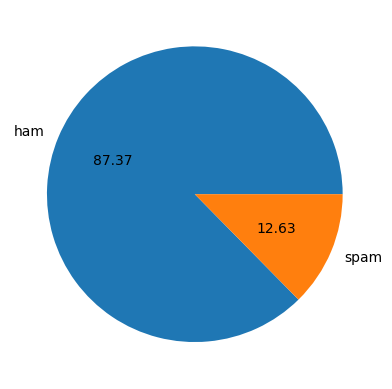

In [234]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

# Text Processing (nltk)

1.Tokenization (split text into words/sentences)

2.Removing punctuation

3.Lowercasing text

In [235]:
#counting length of sentence
df['num_characters']=df['text'].apply(len)

In [236]:
#breaking sentence in to word and storing them in a list and taking len of list
df['num_words']=df['text'].apply(lambda x: len(nltk.word_tokenize((x))))


In [237]:
#number of sentences
#(we will use sent tokenize intead of word tokenize for storing sentence in list and the take len of that list)
df['num_sentences']=df['text'].apply(lambda x :len(nltk.sent_tokenize(x)))


In [238]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [239]:
#decribing min, max number of word, sentences, characters in text
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [240]:
#describing ham(not spam) messages separatly
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()


,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [241]:
#describing spam messages separatly
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()


,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

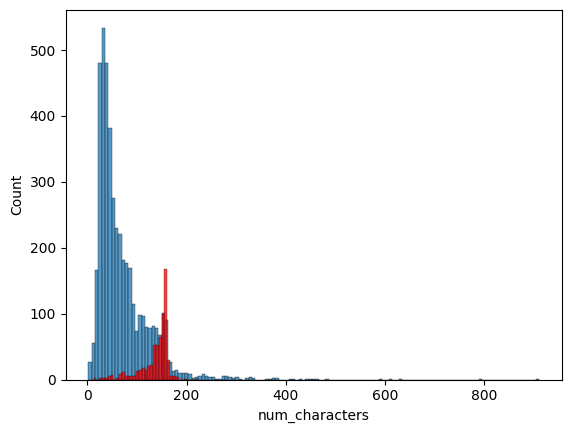

In [242]:
#histogram for ham and spam messages for number of charctera
import seaborn as sns
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

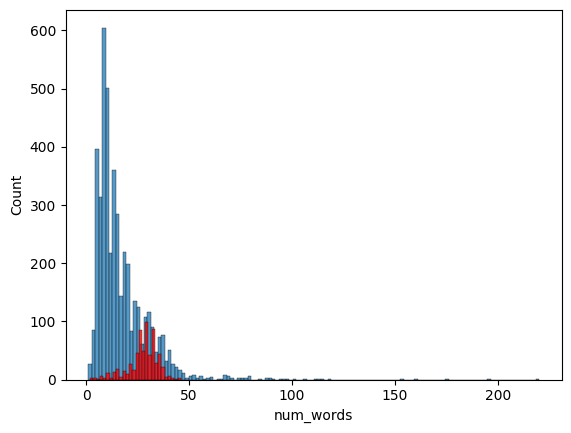

In [243]:
#histogram for ham and spam messages for number of words
import seaborn as sns
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

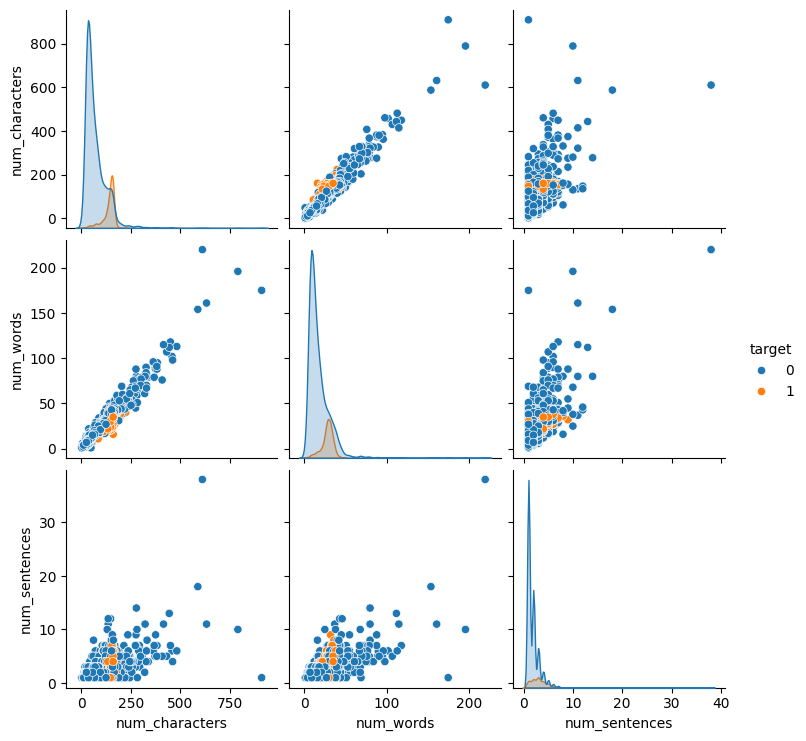

In [244]:
# cheking relation of num_words, num_sentences, num_characters with each other
#hue data ko color ke basis par alag-alag groups me divide karta hai
sns.pairplot(df,hue='target')

<Axes: >

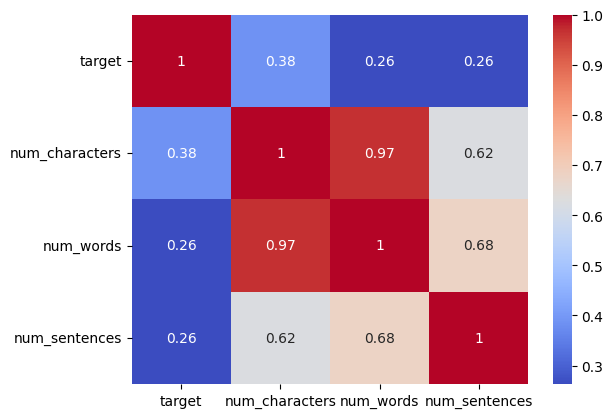

In [245]:
# Correlation bewtween numerical columns
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')


# Data Preprocessing

1.Lowercase<br>
2.Tokenization<br>
3.Removing Special Characters<br>
4.Removing stop word and punctuation<br>
5.Stemming<br>

In [287]:

import string

from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()


In [288]:
STOPWORDS = set("""
a about above after again against all am an and any are aren't as at
be because been before being below between both but by
can can't cannot could couldn't did didn't do does doesn't doing don't down during
each few for from further
had hadn't has hasn't have haven't having he he'd he'll he's her here here's hers herself him himself his how how's
i i'd i'll i'm i've if in into is isn't it it's its itself
let's me more most mustn't my myself
no nor not of off on once only or other ought our ours ourselves out over own
same shan't she she'd she'll she's should shouldn't so some such
than that that's the their theirs them themselves then there there's these they they'd they'll they're they've this those through to too
under until up very
was wasn't we we'd we'll we're we've were weren't what what's when when's where where's which while who who's whom why why's with won't would wouldn't
you you'd you'll you're you've your yours yourself yourselves
""".split())


In [289]:
# from nltk.stem.snowball import stopwords
# def transform_text(text):
#   text=text.lower() # to lower
#   text=nltk.word_tokenize(text) # separating int words
#   # removing special character
#   y=[]
#   for i in text:
#     if i.isalnum():
#       y.append(i)
#   text=y[:] ## list direct copy nhi hoti cloning karni padti hai
#   y.clear()
#   for i in text:
#     if i not in stopwords.words('english') and i not in string.punctuation:
#       y.append(i)

#   text=y[:]
#   y.clear()

#   for i in text:
#     y.append(ps.stem(i))

#   return " ".join(y)
def transform_text(text):
    text = text.lower()
    words = text.split()

    y = []
    for word in words:
        if word.isalnum() and word not in STOPWORDS:
            y.append(ps.stem(word))

    return " ".join(y)





In [290]:
df['transformed_text']=df['text'].apply(transform_text)

In [291]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong avail bugi n great world la e cine g...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok joke wif u
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli u c alreadi
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe live around though


In [292]:
#creating word cloud inspam messages
from wordcloud import WordCloud
wc=WordCloud(width=1000,height=800,min_font_size=10,background_color='white')

In [293]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

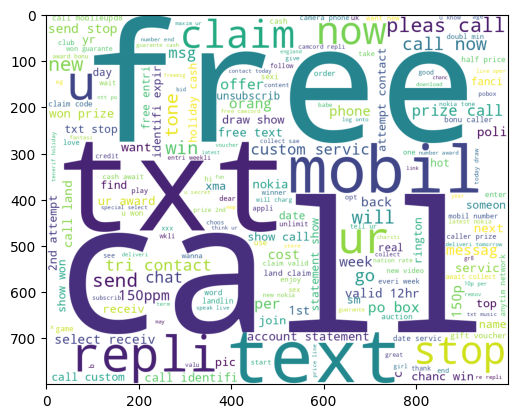

In [294]:
plt.imshow(spam_wc)

In [295]:
#creating word cloud for ham messages
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

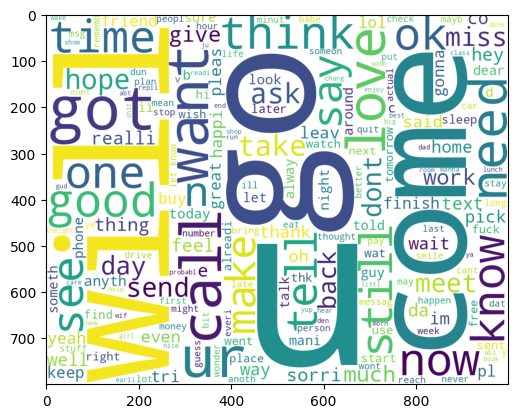

In [296]:
plt.imshow(ham_wc)

In [297]:
#top 30 word used in ham and spam messages
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)


Counter is a special dictionary from Python’s collections module.

It counts how many times each item appears in a list.

In [298]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[('call', 310),
 ('free', 157),
 ('2', 151),
 ('txt', 122),
 ('ur', 119),
 ('text', 112),
 ('mobil', 103),
 ('repli', 100),
 ('u', 96),
 ('claim', 91),
 ('stop', 83),
 ('now', 79),
 ('4', 75),
 ('get', 72),
 ('just', 66),
 ('new', 64),
 ('send', 57),
 ('nokia', 56),
 ('contact', 56),
 ('servic', 55),
 ('prize', 54),
 ('won', 53),
 ('tone', 53),
 ('pleas', 49),
 ('win', 47),
 ('cash', 47),
 ('will', 41),
 ('award', 41),
 ('phone', 40),
 ('per', 39)]

In [299]:
#top 30 word used in ham and ham messages
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)


In [300]:
from collections import Counter
Counter(ham_corpus).most_common(30)

[('u', 794),
 ('go', 379),
 ('get', 339),
 ('will', 310),
 ('just', 273),
 ('2', 272),
 ('come', 251),
 ('like', 225),
 ('got', 221),
 ('call', 214),
 ('know', 208),
 ('want', 198),
 ('ur', 195),
 ('love', 176),
 ('good', 171),
 ('time', 167),
 ('need', 161),
 ('4', 151),
 ('now', 150),
 ('ok', 146),
 ('think', 144),
 ('still', 139),
 ('one', 139),
 ('take', 135),
 ('see', 133),
 ('tell', 131),
 ('make', 129),
 ('r', 120),
 ('say', 119),
 ('n', 118)]

# Model Building

## Vectorisation
* Converting text to numerical data so model will understand it

In [301]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)
# we have used two vectorisatin method but tfidf is more good as it gives preci
#precicion score 1 in mnb so we willl use tfidf and model as mnb (accuracy matter less than precision scor ein tis problem)

In [302]:
X=tfidf.fit_transform(df['transformed_text']).toarray()  #sparse array ko dense array me
# convert tkar lenge .toarray se


In [303]:
#appending numerical columns to X and cheking whether the scor eincreases or not
#not increases
# X = np.hstack((X, df['num_characters'].values.reshape(-1, 1)))


In [304]:
# #scaling se accuracy increasing but precison decreases so we will not use
# from sklearn.preprocessing import MinMaxScaler
# mns=MinMaxScaler()
# X=mns.fit_transform(X)

In [305]:
X.shape

(5169, 3000)

In [306]:
# extrcating y
y=df['target'].values

In [307]:
from sklearn.model_selection import train_test_split


In [308]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [309]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

In [310]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [311]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [312]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.793036750483559
[[706 190]
 [ 24 114]]
0.375


In [313]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))


0.9632495164410058
[[894   2]
 [ 36 102]]
0.9807692307692307


In [314]:
#Bernauli
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))


0.971953578336557
[[892   4]
 [ 25 113]]
0.9658119658119658


In [315]:
# applying some more model to check the accuracy and precision score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [316]:

svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)


In [317]:
# a dictionary with  model object name

clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,

}

In [318]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [319]:

accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9690522243713733
Precision -  0.9491525423728814
For  KN
Accuracy -  0.902321083172147
Precision -  0.9743589743589743
For  NB
Accuracy -  0.9632495164410058
Precision -  0.9807692307692307
For  DT
Accuracy -  0.9303675048355899
Precision -  0.8
For  LR
Accuracy -  0.960348162475822
Precision -  0.9532710280373832
For  RF
Accuracy -  0.9729206963249516
Precision -  0.9824561403508771
For  AdaBoost
Accuracy -  0.9226305609284333
Precision -  0.8536585365853658


In [320]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [321]:
performance_df

,Algorithm,Accuracy,Precision
5,RF,0.972921,0.982456
2,NB,0.963250,0.980769
1,KN,0.902321,0.974359
4,LR,0.960348,0.953271
0,SVC,0.969052,0.949153
6,AdaBoost,0.922631,0.853659
3,DT,0.930368,0.800000


In [322]:
performance_df1 = performance_df.melt(
    id_vars='Algorithm',
    var_name='variable',
    value_name='value'
)


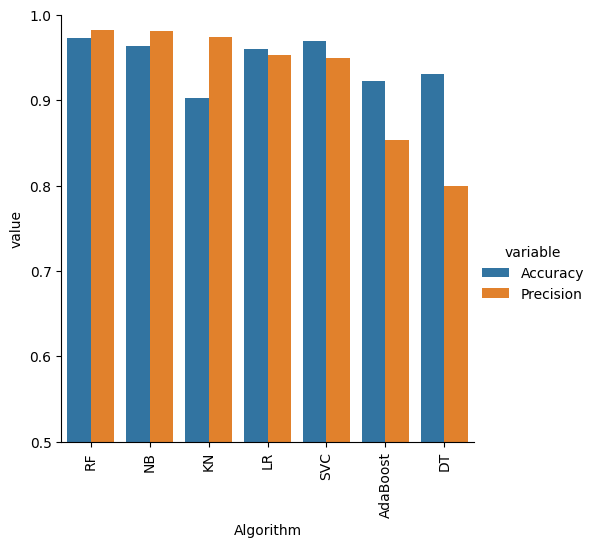

In [323]:
sns.catplot(
    x='Algorithm',
    y='value',
    hue='variable',
    data=performance_df1,
    kind='bar',
    height=5
)

plt.ylim(0.5, 1.0)
plt.xticks(rotation='vertical')
plt.show()


#tunning


In [324]:
# 1. change the max_features parameter of tfidf

Now , we will make pipe line and them convert into model and pickle them

# Pickle

In [325]:
import pickle

In [326]:
#pickling the file
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))